In [1]:
import csv
import pickle
csv.field_size_limit(10 * 1024 * 1024)  # Set the field size limit to 10 MB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC

# Load the CSV file into a list of dictionaries
data = []
with open('token_filter_lemm_medium_and_bbc.csv', encoding="utf8") as csv_file:
    csv_reader = csv.DictReader(csv_file)
    for row in csv_reader:
        data.append(row)

# Extract the lemmatized text and the category from the data
text_data = [row['tokenized_text'] for row in data]
categories = [row['category'] for row in data]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(text_data, categories, test_size=0.2, random_state=42)

# Create a CountVectorizer to convert the lemmatized text into numerical features
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train a linear SVM model on the training data
svm = LinearSVC()
svm.fit(X_train_vec, y_train)

# Save the trained model to a file
with open('svm_model.pkl', 'wb') as f:
    pickle.dump(svm, f)

# Evaluate the model on the testing data
score = svm.score(X_test_vec, y_test)
print(f"Accuracy: {score}")


Accuracy: 0.9639305405266141


c:\Users\223079929\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [2]:
from sklearn.metrics import confusion_matrix
# Evaluate the model on the testing data and create a confusion matrix
y_pred = svm.predict(X_test_vec)
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

[[  103     0     2     0     1   243]
 [    1    56     0     0     0    26]
 [    4     0   102     0     0   372]
 [    5     0     0    79     0    16]
 [    1     0     1     0    72     8]
 [  261     8   440     8     3 37002]]


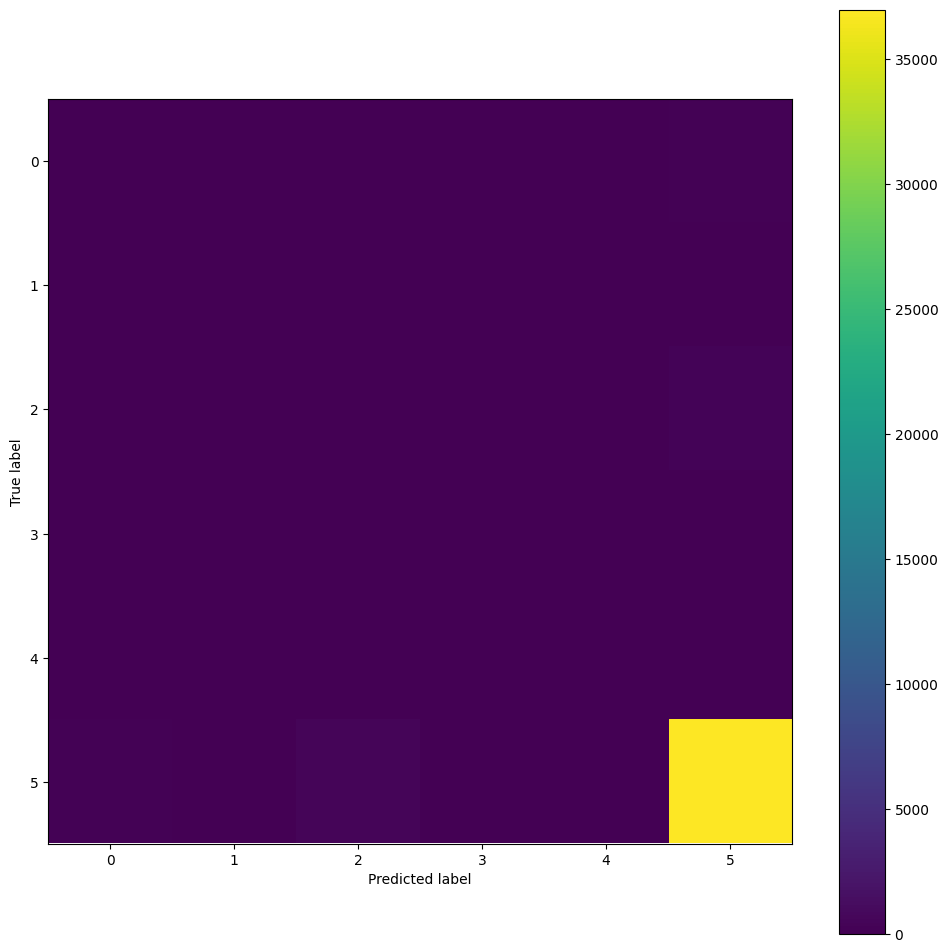

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a heatmap plot of the confusion matrix
plt.figure(figsize=(12, 12))
plt.imshow(conf_matrix)
plt.colorbar()
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

In [9]:
import pickle
text = "Marketing is an essential aspect of any business, as it helps to promote products and services to potential customers. One effective marketing strategy is to use social media platforms to reach a wider audience. By creating engaging content and using targeted advertising, businesses can attract new customers and build brand awareness. Another effective marketing strategy is to use email marketing campaigns. By creating personalized emails that target specific segments of their customer base, businesses can improve their conversion rates and drive more sales. Additionally, businesses can use content marketing to establish themselves as thought leaders in their industry. By creating informative blog posts, videos, and other content that provide value to their target audience, businesses can build trust and establish themselves as experts in their field"
# Load the saved model from a file
with open('svm_model.pkl', 'rb') as f:
    svm = pickle.load(f)

# Define a function to predict the category of new text data
def predict_category(text):
    # Preprocess the text data (e.g., tokenize, lemmatize, etc.)
    # ...

    # Convert the preprocessed text data into numerical features using the CountVectorizer
    X_vec = vectorizer.transform([text])

    # Use the trained SVM model to make predictions on the numerical features
    label = svm.predict(X_vec)[0]

    return label

# Example usage:
predicted_label = predict_category(text)
print(predicted_label)


tech
